# 1. Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from xgboost import XGBClassifier

# 2. Load the dataset (with features)

In [5]:
df = pd.read_csv("../data/BLE_FE.csv")
df = df.drop(columns='window_start')

In [6]:
df.head()

,count_1,count_2,count_3,count_4,count_5,count_6,count_7,count_8,count_9,count_10,...,b2_max,b2_min,b2_norm,b3_mean,b3_std,b3_max,b3_min,b3_norm,unique_beacon_count,location
0,0,0,0,214,0,68,17,0,68,0,...,-93.0,-101.0,796.197212,-94.0,1.007435,-93.0,-95.0,775.187719,9,kitchen
1,0,0,0,214,0,68,17,0,68,0,...,-93.0,-101.0,796.197212,-94.0,1.007435,-93.0,-95.0,775.187719,9,kitchen
2,0,0,0,68,0,0,0,0,0,0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,7,cafeteria
3,0,0,0,68,0,0,0,0,0,0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,9,cafeteria
4,0,0,0,136,17,0,34,0,47,0,...,-92.0,-95.0,640.694935,-95.0,3.045115,-92.0,-98.0,554.216564,11,cafeteria


Text(0, 0.5, 'Count')

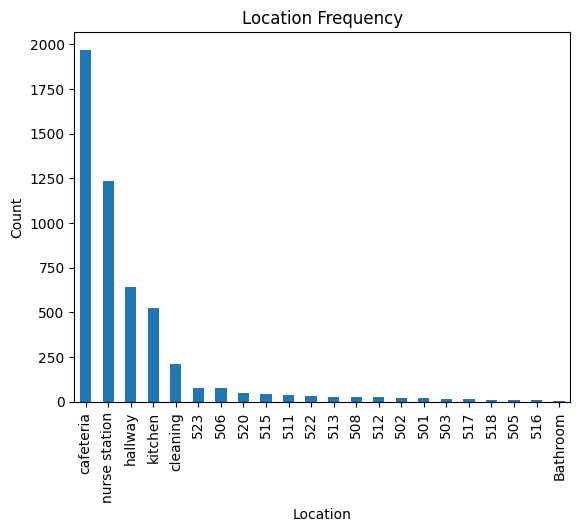

In [7]:
df['location'].value_counts().plot(kind='bar')
plt.title('Location Frequency')
plt.xlabel('Location')
plt.ylabel('Count')

In [8]:
print(df['location'].value_counts())

location
cafeteria        1970
nurse station    1234
hallway           644
kitchen           524
cleaning          212
523                77
506                75
520                46
515                43
511                35
522                33
513                27
508                27
512                26
502                22
501                19
503                12
517                12
518                10
505                 9
516                 8
Bathroom            6
Name: count, dtype: int64


In [9]:
percentages = df['location'].value_counts(normalize=True) * 100
print(percentages)

location
cafeteria        38.848353
nurse station    24.334451
hallway          12.699665
kitchen          10.333268
cleaning          4.180635
523               1.518438
506               1.478998
520               0.907119
515               0.847959
511               0.690199
522               0.650759
513               0.532439
508               0.532439
512               0.512719
502               0.433839
501               0.374680
503               0.236640
517               0.236640
518               0.197200
505               0.177480
516               0.157760
Bathroom          0.118320
Name: proportion, dtype: float64


In [10]:
y = df['location']

In [11]:
X = df.drop(columns='location')
X.head()

,count_1,count_2,count_3,count_4,count_5,count_6,count_7,count_8,count_9,count_10,...,b2_std,b2_max,b2_min,b2_norm,b3_mean,b3_std,b3_max,b3_min,b3_norm,unique_beacon_count
0,0,0,0,214,0,68,17,0,68,0,...,3.225366,-93.0,-101.0,796.197212,-94.0,1.007435,-93.0,-95.0,775.187719,9
1,0,0,0,214,0,68,17,0,68,0,...,3.225366,-93.0,-101.0,796.197212,-94.0,1.007435,-93.0,-95.0,775.187719,9
2,0,0,0,68,0,0,0,0,0,0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,7
3,0,0,0,68,0,0,0,0,0,0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,9
4,0,0,0,136,17,0,34,0,47,0,...,1.247755,-92.0,-95.0,640.694935,-95.0,3.045115,-92.0,-98.0,554.216564,11


In [12]:
split_idx = int(0.8 * len(X))

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y[:split_idx]
y_test  = y[split_idx:]

In [13]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
np.unique(y_train_encoded)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21])

In [14]:
y_test_encoded = le.transform(y_test)
np.unique(y_test_encoded)

array([ 3,  4,  5,  8,  9, 11, 12, 15, 16, 17, 18, 19, 20, 21])

In [15]:
class_counts = np.bincount(y_train_encoded)
class_freq = class_counts / class_counts.sum()

class_weights = {
    c: 1.0 / np.log(1.2 + class_freq[c])
    for c in range(len(class_counts))
}

sample_weights = np.array([class_weights[y] for y in y_train_encoded])

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", X.columns)
    ]
)

In [17]:
rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=12,            
    min_samples_leaf=5,      
    min_samples_split=10,
    max_features="sqrt",
    class_weight="balanced_subsample",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

In [18]:
xgb_model = XGBClassifier(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=15,   
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.5,        
    reg_lambda=2.0,
    objective="multi:softprob",
    tree_method="hist",
    random_state=42
)

In [ ]:
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(le.classes_),

    n_estimators=1000,          # large, rely on early stopping
    learning_rate=0.03,

    max_depth=4,
    min_child_weight=10,
    gamma=1.0,

    subsample=0.7,
    colsample_bytree=0.7,

    tree_method="hist",
    eval_metric="mlogloss",
    random_state=42
)

In [ ]:
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", rf)
])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

In [ ]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", xgb_model)
])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [ ]:
pipeline.fit(X_train, y_train_encoded)

In [ ]:
pipeline.fit(X_train, y_train_encoded, classifier__sample_weight=sample_weights)

In [33]:
y_pred = pipeline.predict(X_test)

In [34]:
probs = pipeline.predict_proba(X_test)

In [35]:
def confidence_smooth(probs, k):
    T, C = probs.shape
    smoothed = np.zeros_like(probs)
    conf = probs.max(axis=1)

    for t in range(T):
        start = max(0, t - k)
        end = min(T, t + k + 1)
        smoothed[t] = np.average(
            probs[start:end],
            axis=0,
            weights=conf[start:end]
        )

    return smoothed
k = 10
smoothed_probs = confidence_smooth(probs, k)
y_pred = smoothed_probs.argmax(axis=1)

In [36]:
accuracy = accuracy_score(y_test_encoded, y_pred)
f1 = f1_score(y_test_encoded, y_pred, average='macro')
precision = precision_score(y_test_encoded, y_pred, average='macro')
recall = recall_score(y_test_encoded, y_pred, average='macro')

print(f"Accuracy: {accuracy:.2f}")
print(f"Macro F1 score: {f1:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

Accuracy: 0.32
Macro F1 score: 0.13
Precision: 0.13
Recall: 0.16


c:\Users\laber\MASc\Repos\Thunderbolts-W\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\laber\MASc\Repos\Thunderbolts-W\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


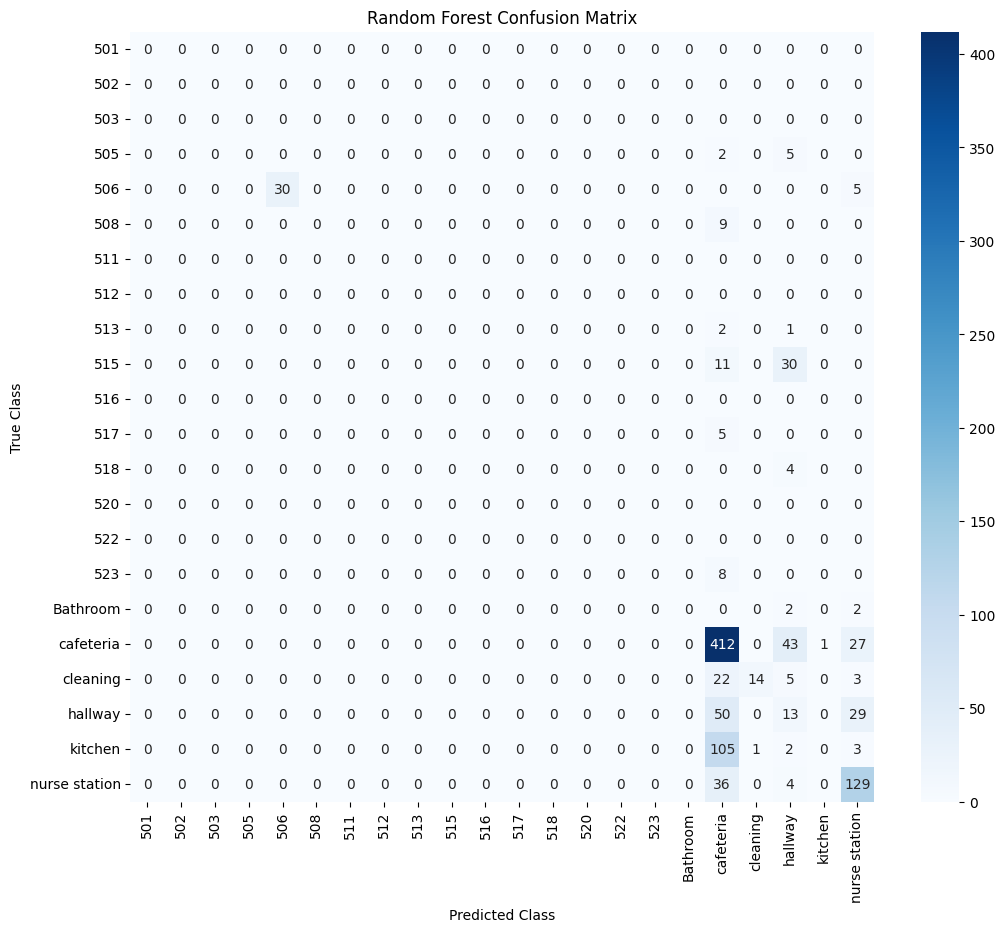

In [24]:
cm = confusion_matrix(y_test_encoded, y_pred, labels=range(len(le.classes_)))
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()